In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

import lightgbm as lgb
import optuna
from sklearn.metrics import root_mean_squared_error, r2_score

from scipy.stats import randint

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../inputs/dataset_v2_fs_top60_+2.csv")
df = df.sort_values("fecha")

## Pre-procesamiento

In [3]:
df = df.sort_values("fecha")
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

In [4]:
df["fecha"].describe()

count                              643
mean     2024-04-28 15:18:11.757387264
min                2023-01-02 00:00:00
25%                2023-08-29 12:00:00
50%                2024-05-02 00:00:00
75%                2024-12-24 12:00:00
max                2025-08-27 00:00:00
Name: fecha, dtype: object

In [5]:
df = df.rename(columns={
    "merval_apertura_+2": "merval",
})

In [6]:
# Asegurarnos que no quedo ninguna fila con NA en la variable a predecir

print(df.loc[df['merval'].isna()].shape[0])

df = df.loc[df['merval'].notna()]

0


In [7]:
# chequeo de cuantos NAs tenemos en cada columna
pd.DataFrame(
    {'df (N)': df.isna().sum(),
    'df (%)': round(df.isna().sum()/df.shape[0]*100,1)}
)


,df (N),df (%)
fecha,0,0.0
merval_cierre,0,0.0
merval_maximo,0,0.0
emae_tendencia_ciclo_ma_5,0,0.0
badlar_ma_3,0,0.0
...,...,...
m2_diff3,0,0.0
base_monetaria_diff10,0,0.0
tasa_prestamos_personales_hp_rm20,0,0.0
prestamos_privados_ars_diff1,0,0.0


In [8]:
# Eliminar filas con NaN creadas por los lags (las primeras 5 si usamos hasta lags de 5 dias)
df = df.dropna().copy()

In [9]:
y = df["merval"]
# X = df.drop(columns=["merval"]) # no estoy del todo seguro si tenemos que eliminar fecha
X = df.drop(columns=["merval","fecha"]) # no estoy del todo seguro si tenemos que eliminar fecha o si la convertimos a numerica

## Train-Test Split

In [10]:
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(X_train.shape)
print(X_test.shape)

(514, 60)
(129, 60)


## Funcion objetivo para Optuna y Cross-Validation

In [11]:
max_lag = 5 # por el moving average 5

In [12]:
def objective(trial):
    # Espacios de búsqueda ajustados para ~515 filas de entrenamiento y 60 features
    params = {
        "objective": "regression",
        "metric": "rmse",
        "boosting_type": "gbdt",
        "verbosity": -1,
        "random_state": 42,

        # Aprendizaje: rango más amplio con dataset más grande
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),

        # Complejidad del árbol: podemos permitir mayor complejidad
        "num_leaves": trial.suggest_int("num_leaves", 15, 63),
        "max_depth": trial.suggest_int("max_depth", 3, 8),

        # Mínimos más exigentes con más datos
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 80),

        # Regularizaciones L1/L2
        "lambda_l1": trial.suggest_float("lambda_l1", 0.01, 3.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 0.01, 10.0, log=True),

        # Permitimos búsqueda de min_split_gain con más datos
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 1.0),

        # Submuestreo: rango similar pero podemos ser más agresivos
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),

        # Más árboles disponibles con dataset más grande
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "n_jobs": -1,
    }

    # --------- Ajustes dependientes (evitan configuraciones inválidas) ---------
    eff = params.copy()

    # Alinear num_leaves con max_depth: num_leaves <= 2**max_depth cuando max_depth>0
    if eff["max_depth"] > 0:
        eff["num_leaves"] = min(eff["num_leaves"], 2 ** eff["max_depth"])

    # Activar frecuencia de bagging si hay subsample<1
    if eff["subsample"] < 1.0:
        eff["subsample_freq"] = 1

    # --------------------------------------------------------------------------

    # Cross validation con más splits y test sets más grandes
    n_splits = 5  # Más folds con más datos
    test_size = 20  # ~1 mes de validación
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size, gap=max_lag)

    rmses = []
    for tr_idx, va_idx in tscv.split(X_train):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

        model = lgb.LGBMRegressor(**eff)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="rmse",
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
        )

        # Predicción usando los árboles óptimos según early stopping
        preds = model.predict(X_va, num_iteration=model.best_iteration_)
        rmse = mean_squared_error(y_va, preds, squared=False)
        rmses.append(rmse)

    return float(np.mean(rmses))

In [13]:
study = optuna.create_study(direction="minimize", study_name="lgbm_merval")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Mejores hiperparámetros:", study.best_params)
print("Mejor RMSE CV promedio:", study.best_value)

[I 2025-11-10 19:23:52,198] A new study created in memory with name: lgbm_merval


  0%|          | 0/50 [00:00<?, ?it/s]

c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarnin

[I 2025-11-10 19:23:53,342] Trial 0 finished with value: 286442.9002088463 and parameters: {'learning_rate': 0.02662617824213448, 'num_leaves': 47, 'max_depth': 6, 'min_child_samples': 31, 'lambda_l1': 1.1031007772669097, 'lambda_l2': 4.314474892112079, 'min_split_gain': 0.33247659788770434, 'subsample': 0.8634296469435316, 'colsample_bytree': 0.9676631419914037, 'n_estimators': 462}. Best is trial 0 with value: 286442.9002088463.


c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarnin

...

[I 2025-11-10 19:24:22,540] Trial 47 finished with value: 276338.40453656134 and parameters: {'learning_rate': 0.06098825955500018, 'num_leaves': 31, 'max_depth': 8, 'min_child_samples': 23, 'lambda_l1': 0.32378045817654244, 'lambda_l2': 0.06060370762434632, 'min_split_gain': 0.41911644889802846, 'subsample': 0.6276279802164506, 'colsample_bytree': 0.8367356829603425, 'n_estimators': 430}. Best is trial 14 with value: 270129.7963675258.


c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarnin

[I 2025-11-10 19:24:22,827] Trial 48 finished with value: 510677.88549651357 and parameters: {'learning_rate': 0.01241954427811119, 'num_leaves': 27, 'max_depth': 6, 'min_child_samples': 64, 'lambda_l1': 0.5515728985688958, 'lambda_l2': 0.6025412430372121, 'min_split_gain': 0.6079176221022178, 'subsample': 0.6531765117631588, 'colsample_bytree': 0.7306106943457256, 'n_estimators': 262}. Best is trial 14 with value: 270129.7963675258.


c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarnin

[I 2025-11-10 19:24:23,201] Trial 49 finished with value: 320297.1259192082 and parameters: {'learning_rate': 0.07775416862838712, 'num_leaves': 15, 'max_depth': 3, 'min_child_samples': 35, 'lambda_l1': 0.7785216799511279, 'lambda_l2': 1.1236511127926254, 'min_split_gain': 0.9995616810369242, 'subsample': 0.616051673940078, 'colsample_bytree': 0.5621788485024937, 'n_estimators': 475}. Best is trial 14 with value: 270129.7963675258.
Mejores hiperparámetros: {'learning_rate': 0.08422252302477516, 'num_leaves': 15, 'max_depth': 4, 'min_child_samples': 20, 'lambda_l1': 0.5001872826817239, 'lambda_l2': 0.06335552624683442, 'min_split_gain': 0.6408105202736714, 'subsample': 0.6355006437884629, 'colsample_bytree': 0.8568318772863357, 'n_estimators': 271}
Mejor RMSE CV promedio: 270129.7963675258


In [14]:
study.best_params

{'learning_rate': 0.08422252302477516,
 'num_leaves': 15,
 'max_depth': 4,
 'min_child_samples': 20,
 'lambda_l1': 0.5001872826817239,
 'lambda_l2': 0.06335552624683442,
 'min_split_gain': 0.6408105202736714,
 'subsample': 0.6355006437884629,
 'colsample_bytree': 0.8568318772863357,
 'n_estimators': 271}

In [15]:
best_params = study.best_params
best_model = lgb.LGBMRegressor(**best_params)
best_model.fit(X_train, y_train)

[LightGBM] [Warning] lambda_l1 is set=0.5001872826817239, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.5001872826817239
[LightGBM] [Warning] lambda_l2 is set=0.06335552624683442, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.06335552624683442
[LightGBM] [Warning] lambda_l1 is set=0.5001872826817239, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.5001872826817239
[LightGBM] [Warning] lambda_l2 is set=0.06335552624683442, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.06335552624683442
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000461 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8986
[LightGBM] [Info] Number of data points in the train set: 514, number of used features: 60
[LightGBM] [Info] Start training from score 1110105.107855
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wi

LGBMRegressor(colsample_bytree=0.8568318772863357, lambda_l1=0.5001872826817239,
              lambda_l2=0.06335552624683442, learning_rate=0.08422252302477516,
              max_depth=4, min_split_gain=0.6408105202736714, n_estimators=271,
              num_leaves=15, subsample=0.6355006437884629)

## Test

In [16]:
y_pred = best_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Holdout RMSE: {rmse:.4f}")
print(f"Holdout R²:   {r2:.4f}")


[LightGBM] [Warning] lambda_l1 is set=0.5001872826817239, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.5001872826817239
[LightGBM] [Warning] lambda_l2 is set=0.06335552624683442, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.06335552624683442
Holdout RMSE: 131790.6843
Holdout R²:   -0.0331


In [17]:
# Agregamos las predicciones al dataframe original (solo para las filas de test)
df.loc[y_test.index, "pred_merval"] = y_pred

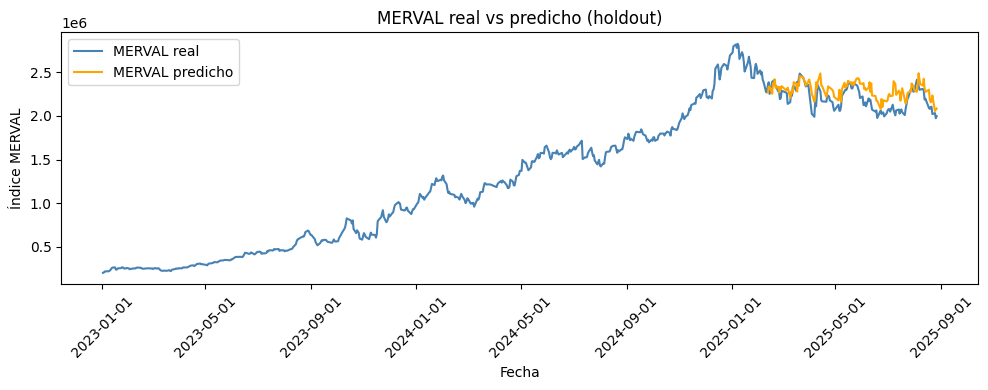

In [18]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df["fecha"], df["merval"], label="MERVAL real", color="steelblue")
ax.plot(df["fecha"], df["pred_merval"], label="MERVAL predicho", color="orange")

ax.set_title("MERVAL real vs predicho (holdout)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


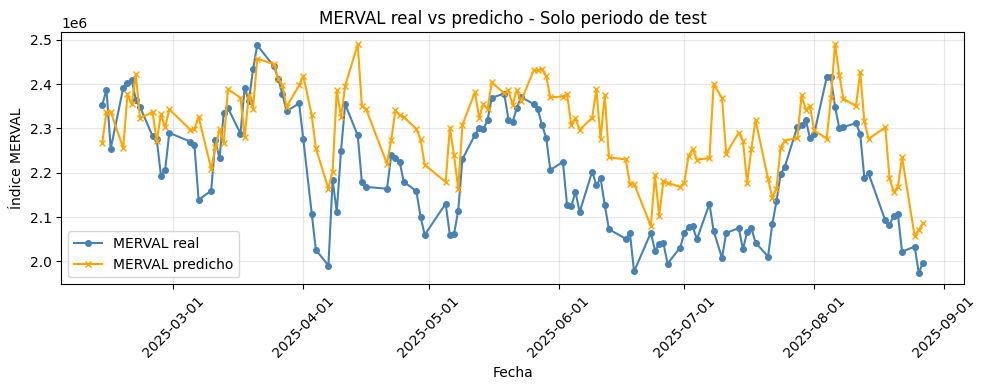

In [19]:
# Gráfico detallado solo para el periodo de test
df_test = df.loc[y_test.index]

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df_test["fecha"], df_test["merval"], label="MERVAL real", color="steelblue", marker='o', markersize=4)
ax.plot(df_test["fecha"], df_test["pred_merval"], label="MERVAL predicho", color="orange", marker='x', markersize=4)

ax.set_title("MERVAL real vs predicho - Solo periodo de test")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
df_test

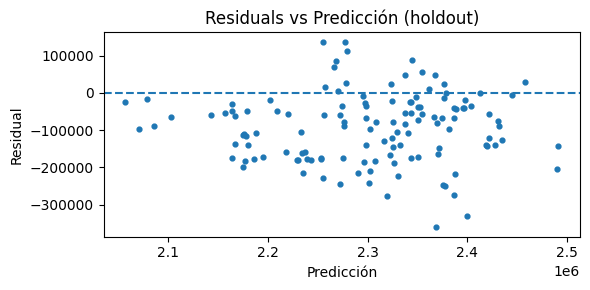

In [20]:
res = y_test - y_pred
plt.figure(figsize=(6,3))
plt.scatter(y_pred, res, s=12)
plt.axhline(0, ls="--")
plt.xlabel("Predicción")
plt.ylabel("Residual")
plt.title("Residuals vs Predicción (holdout)")
plt.tight_layout(); plt.show()


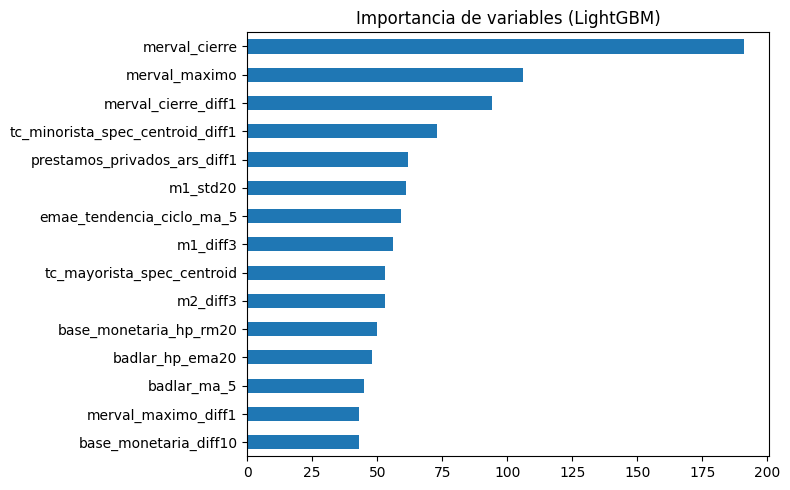

In [21]:
imp = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)
imp.tail(15).plot(kind="barh", figsize=(8,5), title="Importancia de variables (LightGBM)")
plt.tight_layout()
plt.show()
